Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== ADF Sebelum Box-Cox ===
ADF Statistic: 2.24989267283256
p-value: 0.9989211091268941
Critical Value 1%: -3.4582467982399105
Critical Value 5%: -2.8738137461081323
Critical Value 10%: -2.5733111490323846

Lambda Box-Cox: 0.39245922189229876

=== ADF Setelah Box-Cox ===
ADF Statistic: 0.7304424711819806
p-value: 0.9904262260393921
Critical Value 1%: -3.4582467982399105
Critical Value 5%: -2.8738137461081323
Critical Value 10%: -2.5733111490323846


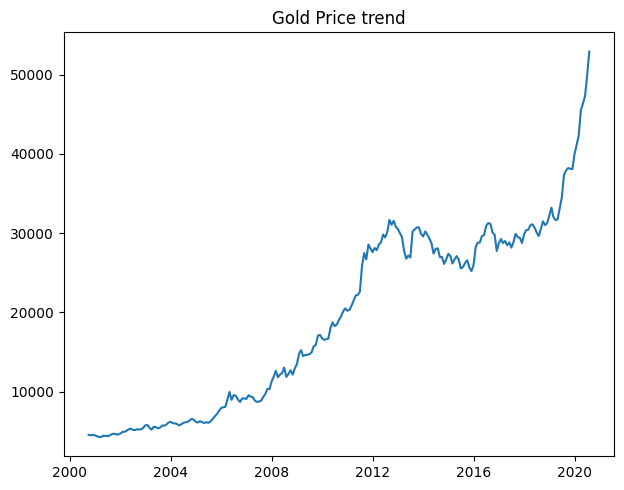

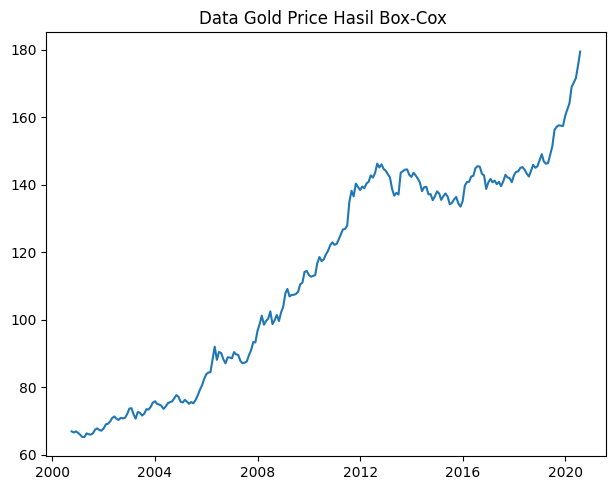

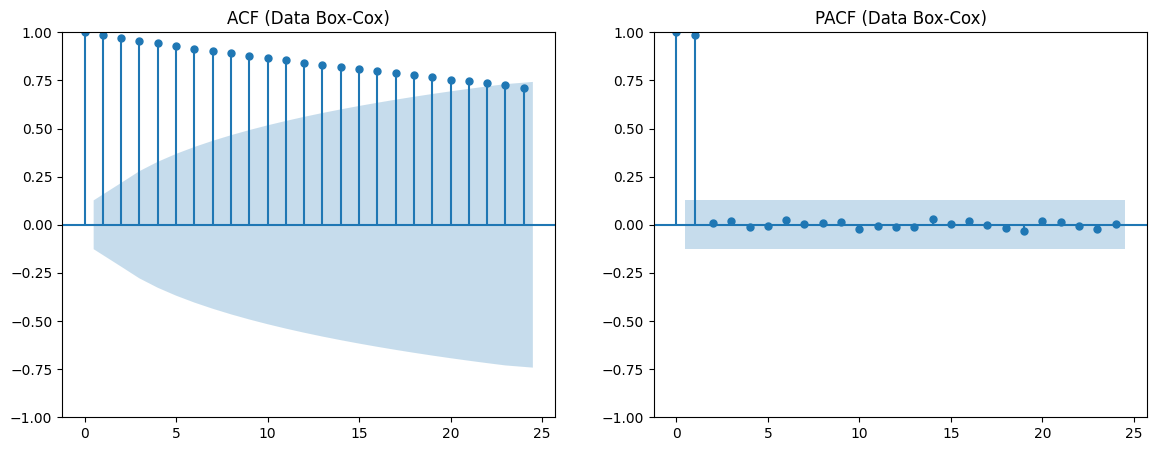

In [ ]:
# ===========================
# IMPORT LIBRARY
# ===========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from google.colab import drive
drive.mount('/content/drive')

# ===========================
# 1. LOAD DATA DARI GOOGLE DRIVE
# ===========================
file_path = "/content/drive/My Drive/Ekonometrika/Gold Price.xlsx"  # Ganti jika folder berbeda
df = pd.read_excel(file_path)

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Kolom yang digunakan
y = df['Gold Price'].astype(float)

# ===========================
# 2. UJI STASIONERITAS ADF SEBELUM BOX-COX
# ===========================
print("=== ADF Sebelum Box-Cox ===")
adf_orig = adfuller(y)
print(f"ADF Statistic: {adf_orig[0]}")
print(f"p-value: {adf_orig[1]}")
for key, value in adf_orig[4].items():
    print(f"Critical Value {key}: {value}")

# ===========================
# 2. TRANSFORMASI BOX-COX
# ===========================
y_boxcox, lambda_bc = boxcox(y)
print("\nLambda Box-Cox:", lambda_bc)

# jadikan series
y_bc = pd.Series(y_boxcox, index=y.index)

# ===========================
# 3. PLOT SEBELUM & SESUDAH BOXCOX
# ===========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(y)
plt.title("Gold Price trend")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
plt.plot(y_bc)
plt.title(f"Data Gold Price Hasil Box-Cox ")

plt.tight_layout()
plt.show()
# ===========================
# 4. UJI ADF SETELAH BOX-COX
# ===========================
print("\n=== ADF Setelah Box-Cox ===")
adf_boxcox = adfuller(y_bc)
print(f"ADF Statistic: {adf_boxcox[0]}")
print(f"p-value: {adf_boxcox[1]}")
for key, value in adf_boxcox[4].items():
    print(f"Critical Value {key}: {value}")

# ===========================
# 6. ACF & PACF SETELAH BOXCOX
# ===========================
fig, ax = plt.subplots(1,2,figsize=(14,5))

plot_acf(y_bc, ax=ax[0])
ax[0].set_title("ACF (Data Box-Cox)")

plot_pacf(y_bc, ax=ax[1])
ax[1].set_title("PACF (Data Box-Cox)")

plt.show()


=== ADF Setelah Differencing (d=1) ===
ADF Statistic: -13.237513517463805
p-value: 9.313785835356328e-25
Critical Value 1%: -3.4582467982399105
Critical Value 5%: -2.8738137461081323
Critical Value 10%: -2.5733111490323846


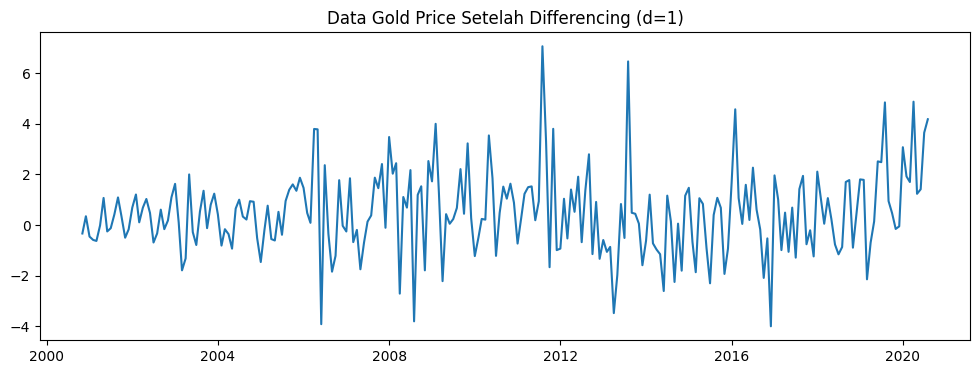

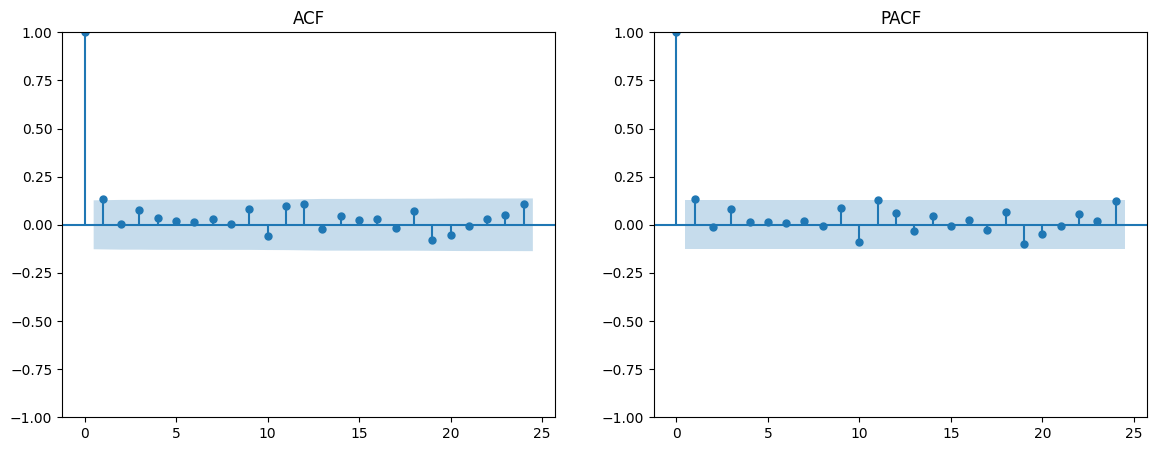

In [ ]:
# ===========================
# 5. DIFFERENCING (d = 1)
# ===========================
y_diff = y_bc.diff().dropna()

# ===========================
# 6. UJI ADF SETELAH DIFFERENCING
# ===========================
print("=== ADF Setelah Differencing (d=1) ===")
adf_diff = adfuller(y_diff)
print(f"ADF Statistic: {adf_diff[0]}")
print(f"p-value: {adf_diff[1]}")
for key, value in adf_diff[4].items():
    print(f"Critical Value {key}: {value}")

# ===========================
# 7. PLOT HASIL DIFFERENCING
# ===========================
plt.figure(figsize=(12,4))
plt.plot(y_diff)
plt.title("Data Gold Price Setelah Differencing (d=1)")
plt.show()

# ===========================
# 8. ACF & PACF SETELAH DIFFERENCING
# ===========================
fig, ax = plt.subplots(1,2,figsize=(14,5))

plot_acf(y_diff, ax=ax[0])
ax[0].set_title("ACF")

plot_pacf(y_diff, ax=ax[1])
ax[1].set_title("PACF")

plt.show()


In [ ]:
import warnings
import itertools
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# ===========================
# Grid Search ARIMA(p,1,q)
# ===========================

p_values = range(0, 6)
d_value = 1
q_values = range(0, 6)

results = []

for p in p_values:
    for q in q_values:
        try:
            model = sm.tsa.ARIMA(y_bc, order=(p, d_value, q))
            model_fit = model.fit()
            results.append({
                "p": p,
                "d": d_value,
                "q": q,
                "AIC": model_fit.aic
            })
            print(f"ARIMA({p},{d_value},{q}) AIC: {model_fit.aic:.4f}")
        except:
            continue

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by AIC
results_df_sorted = results_df.sort_values("AIC").reset_index(drop=True)

print("\n=== 10 Model Terbaik Berdasarkan AIC ===")
print(results_df_sorted.head(10))


ARIMA(0,1,0) AIC: 927.8532
ARIMA(0,1,1) AIC: 920.8725
ARIMA(0,1,2) AIC: 922.5978
ARIMA(0,1,3) AIC: 921.4520
ARIMA(0,1,4) AIC: 922.4856
ARIMA(0,1,5) AIC: 923.6116
ARIMA(1,1,0) AIC: 920.1575
ARIMA(1,1,1) AIC: 911.2107
ARIMA(1,1,2) AIC: 911.6476
ARIMA(1,1,3) AIC: 912.8205
ARIMA(1,1,4) AIC: 914.6290
ARIMA(1,1,5) AIC: 916.5395
ARIMA(2,1,0) AIC: 921.6938
ARIMA(2,1,1) AIC: 911.8492
ARIMA(2,1,2) AIC: 912.2322
ARIMA(2,1,3) AIC: 914.2133
ARIMA(2,1,4) AIC: 916.1806
ARIMA(2,1,5) AIC: 918.1799
ARIMA(3,1,0) AIC: 919.5841
ARIMA(3,1,1) AIC: 913.0121
ARIMA(3,1,2) AIC: 914.2141
ARIMA(3,1,3) AIC: 912.9239
ARIMA(3,1,4) AIC: 914.8948
ARIMA(3,1,5) AIC: 909.5919
ARIMA(4,1,0) AIC: 920.7948
ARIMA(4,1,1) AIC: 914.7038
ARIMA(4,1,2) AIC: 916.1800
ARIMA(4,1,3) AIC: 914.5650
ARIMA(4,1,4) AIC: 918.6013
ARIMA(4,1,5) AIC: 922.4783
ARIMA(5,1,0) AIC: 921.9350
ARIMA(5,1,1) AIC: 916.5527
ARIMA(5,1,2) AIC: 918.1796
ARIMA(5,1,3) AIC: 917.2756
ARIMA(5,1,4) AIC: 920.3858
ARIMA(5,1,5) AIC: 914.4667

=== 10 Model Terbaik Berdas

In [ ]:
# ===========================
# 0. LIBRARY
# ===========================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import boxcox
from scipy.special import inv_boxcox

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

from sklearn.metrics import mean_squared_error, mean_absolute_error

# ===========================
# 1. LOAD DATA
# ===========================
df = pd.read_excel("/content/drive/My Drive/Ekonometrika/Gold Price.xlsx")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

y = df['Gold Price'].astype(float)

# ===========================
# 2. BOX–COX TRANSFORMATION
# ===========================
y_bc, lambda_bc = boxcox(y)
y_bc = pd.Series(y_bc, index=y.index)

print("Lambda Box-Cox:", lambda_bc)

# ===========================
# 9. TRAIN–TEST SPLIT (80/20)
# ===========================
train_size = int(len(y_bc) * 0.8)
train = y_bc.iloc[:train_size]
test  = y_bc.iloc[train_size:]

# ===========================
# 10. GRID SEARCH ARIMA + SIGNIFIKANSI PARAMETER
# ===========================
p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 4)

best_score = np.inf
best_order = None
best_metrics = None

print("\n=== GRID SEARCH ARIMA + PARAMETER ESTIMATION ===")

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train, order=(p,d,q))
                model_fit = model.fit()

                pred = model_fit.forecast(steps=len(test))

                mse = mean_squared_error(test, pred)
                mae = mean_absolute_error(test, pred)
                aic = model_fit.aic

                print("\n----------------------------------------")
                print(f"ARIMA{(p,d,q)}")
                print(f"MSE = {mse:.4f} | MAE = {mae:.4f} | AIC = {aic:.2f}")

                # ===========================
                # 11. ESTIMASI PARAMETER
                # ===========================
                params = model_fit.params
                pvalues = model_fit.pvalues

                print("\nEstimasi Parameter:")
                for param in params.index:
                    signif = "Signifikan" if pvalues[param] < 0.05 else "Tidak signifikan"
                    print(f"{param:10s} = {params[param]:8.4f} | p-value = {pvalues[param]:.4f} | {signif}")

                # ===========================
                # SIMPAN MODEL TERBAIK
                # ===========================
                if mse < best_score:
                    best_score = mse
                    best_order = (p,d,q)
                    best_metrics = {
                        "MSE": mse,
                        "MAE": mae,
                        "AIC": aic
                    }

            except Exception as e:
                continue


# ===========================
# 5. HASIL BEST MODEL
# ===========================
print("\n==============================")
print("Best ARIMA order:", best_order)
print("MSE (Validation):", best_metrics["MSE"])
print("MAE (Validation):", best_metrics["MAE"])
print("AIC:", best_metrics["AIC"])
print("==============================")

# ===========================
# 6. FIT BEST MODEL
# ===========================
best_model = ARIMA(train, order=best_order).fit()
print(best_model.summary())

# ===========================
# 7. UJI SIGNIFIKANSI PARAMETER
# ===========================
print("\n=== Uji Signifikansi Parameter ===")
print(best_model.pvalues)
print("Parameter signifikan jika p-value < 0.05")

# ===========================
# 12. UJI LJUNG–BOX (BEST MODEL)
# ===========================
print("\n=== Uji Ljung–Box ===")
lb_test = acorr_ljungbox(best_model.resid, lags=[10], return_df=True)
print(lb_test)

if lb_test['lb_pvalue'].values[0] > 0.05:
    print("Kesimpulan: Residual bersifat white noise")
else:
    print("Kesimpulan: Residual masih mengandung autokorelasi")

# ===========================
# 9. UJI HETEROSKEDASTISITAS (ARCH)
# ===========================
print("\n=== Uji ARCH ===")
arch_test = het_arch(best_model.resid)

print(f"LM Stat     : {arch_test[0]:.4f}")
print(f"LM P-value  : {arch_test[1]:.4f}")
print(f"F Stat      : {arch_test[2]:.4f}")
print(f"F P-value   : {arch_test[3]:.4f}")

if arch_test[1] > 0.05:
    print("Kesimpulan: Tidak terdapat heteroskedastisitas")
else:
    print("Kesimpulan: Terdapat heteroskedastisitas")

# ===========================
# 10. ROLLING FORECAST (1-STEP)
# ===========================
history = list(train)
rolling_predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=best_order)
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    rolling_predictions.append(yhat)

    history.append(test.iloc[t])

# ===========================
# 11. AKURASI ROLLING FORECAST
# ===========================
mse_roll = mean_squared_error(test, rolling_predictions)
mae_roll = mean_absolute_error(test, rolling_predictions)

print("\n==============================")
print("HASIL ROLLING FORECAST")
print("MSE:", mse_roll)
print("MAE:", mae_roll)
print("==============================")

# ===========================
# 12. INVERSE BOX–COX
# ===========================
test_original = inv_boxcox(test, lambda_bc)
rolling_original = inv_boxcox(rolling_predictions, lambda_bc)

print("\nContoh 10 data awal:")
for i in range(10):
    print(f"Aktual = {test_original.iloc[i]:.2f} | Prediksi = {rolling_original[i]:.2f}")


Mounted at /content/drive
Lambda Box-Cox: 0.39245922189229876

=== GRID SEARCH ARIMA + PARAMETER ESTIMATION ===


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



----------------------------------------
ARIMA(0, 0, 0)
MSE = 2101.5895 | MAE = 44.6697 | AIC = 1826.61

Estimasi Parameter:
const      = 104.6818 | p-value = 0.0000 | Signifikan
sigma2     = 816.1375 | p-value = 0.0000 | Signifikan


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



----------------------------------------
ARIMA(0, 0, 1)
MSE = 2074.1944 | MAE = 44.2189 | AIC = 1581.15

Estimasi Parameter:
const      = 104.6921 | p-value = 0.0000 | Signifikan
ma.L1      =   0.9633 | p-value = 0.0000 | Signifikan
sigma2     = 220.3486 | p-value = 0.0000 | Signifikan


...


----------------------------------------
ARIMA(3, 1, 2)
MSE = 68.2653 | MAE = 7.0133 | AIC = 724.52

Estimasi Parameter:
ar.L1      =   0.2824 | p-value = 0.3071 | Tidak signifikan
ar.L2      =   0.6902 | p-value = 0.0264 | Signifikan
ar.L3      =   0.0105 | p-value = 0.9002 | Tidak signifikan
ma.L1      =  -0.1815 | p-value = 0.4862 | Tidak signifikan
ma.L2      =  -0.7519 | p-value = 0.0026 | Signifikan
sigma2     =   2.4838 | p-value = 0.0000 | Signifikan


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used


----------------------------------------
ARIMA(3, 1, 3)
MSE = 68.0469 | MAE = 7.4993 | AIC = 720.66

Estimasi Parameter:
ar.L1      =  -0.3931 | p-value = 0.0000 | Signifikan
ar.L2      =   0.4789 | p-value = 0.0000 | Signifikan
ar.L3      =   0.9135 | p-value = 0.0000 | Signifikan
ma.L1      =   0.4968 | p-value = 0.0000 | Signifikan
ma.L2      =  -0.4962 | p-value = 0.0000 | Signifikan
ma.L3      =  -0.9845 | p-value = 0.0000 | Signifikan
sigma2     =   2.3623 | p-value = 0.0000 | Signifikan

Best ARIMA order: (1, 1, 2)
MSE (Validation): 67.28273773201687
MAE (Validation): 7.0342185926418805
AIC: 722.0850625225959
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  191
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -357.043
Date:                Thu, 18 Dec 2025   AIC                            722.085
Time:                        22:18:01   BIC                

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


HASIL ROLLING FORECAST
MSE: 3.044213916780864
MAE: 1.3648750704655221

Contoh 10 data awal:
Aktual = 31178.00 | Prediksi = 31417.88
Aktual = 30071.00 | Prediksi = 31291.92
Aktual = 29796.00 | Prediksi = 30071.83
Aktual = 27754.00 | Prediksi = 29857.36
Aktual = 28746.00 | Prediksi = 27603.27
Aktual = 29265.00 | Prediksi = 28864.05
Aktual = 28758.00 | Prediksi = 29354.18
Aktual = 29010.00 | Prediksi = 28763.55
Aktual = 28471.00 | Prediksi = 29076.19
Aktual = 28823.00 | Prediksi = 28465.27



Nilai R² (Rolling Forecast): 0.9727678884933996


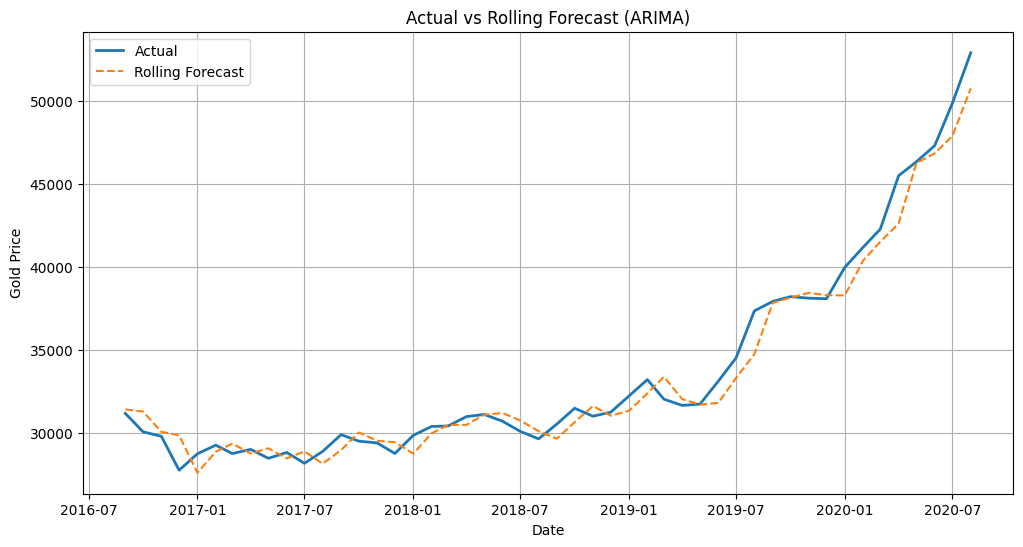

In [ ]:
# ===========================
# 12. HITUNG R²
# ===========================
from sklearn.metrics import r2_score

r2 = r2_score(test_original, rolling_original)
print("\nNilai R² (Rolling Forecast):", r2)


# ===========================
# 13. PLOT ACTUAL vs PREDIKSI
# ===========================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test_original.index, test_original.values, label='Actual', linewidth=2)
plt.plot(test_original.index, rolling_original, label='Rolling Forecast', linestyle='--')

plt.title('Actual vs Rolling Forecast (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



=== SUMMARY ARIMA(1,1,1) ===
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  191
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -357.471
Date:                Thu, 18 Dec 2025   AIC                            720.943
Time:                        22:18:56   BIC                            730.684
Sample:                    10-01-2000   HQIC                           724.889
                         - 08-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9888      0.017     59.591      0.000       0.956       1.021
ma.L1         -0.9574      0.030    -31.502      0.000      -1.017      -0.898
sigma2         2.5162 

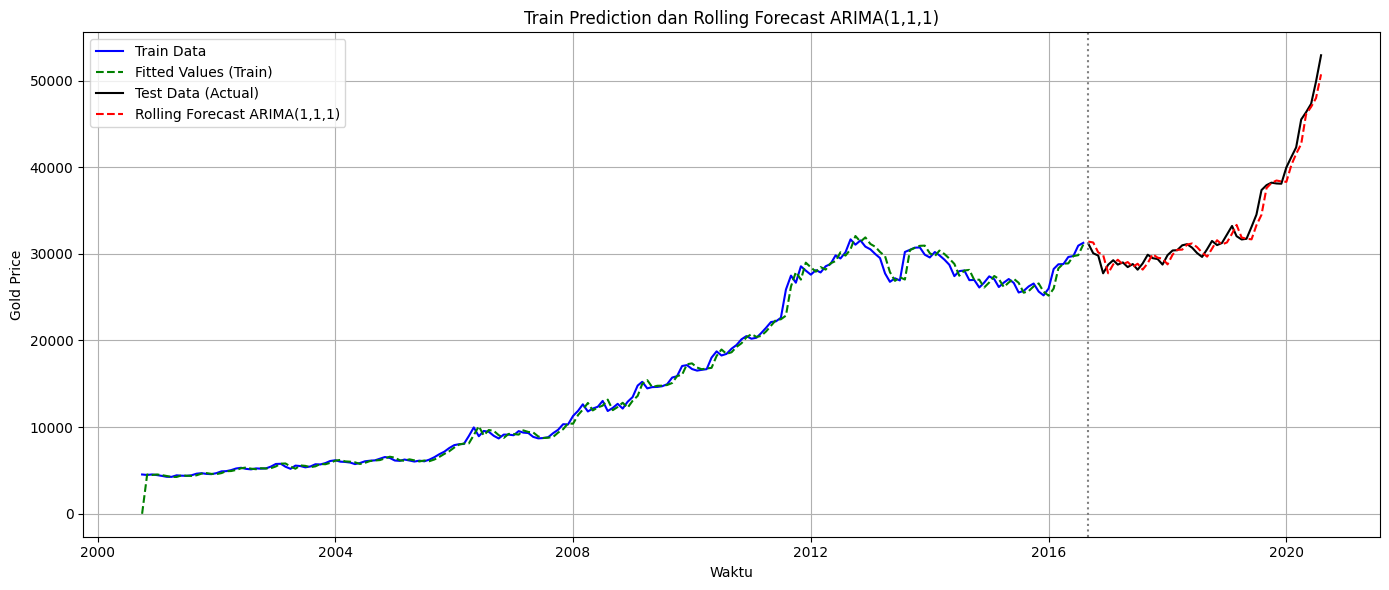

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



=== Forecast 12 Bulan ke Depan ===
2020-09-01    54006.98
2020-10-01    55094.57
2020-11-01    56179.49
2020-12-01    57261.44
2021-01-01    58340.18
2021-02-01    59415.43
2021-03-01    60486.97
2021-04-01    61554.54
2021-05-01    62617.92
2021-06-01    63676.91
2021-07-01    64731.28
2021-08-01    65780.84
Freq: MS, Name: predicted_mean, dtype: float64


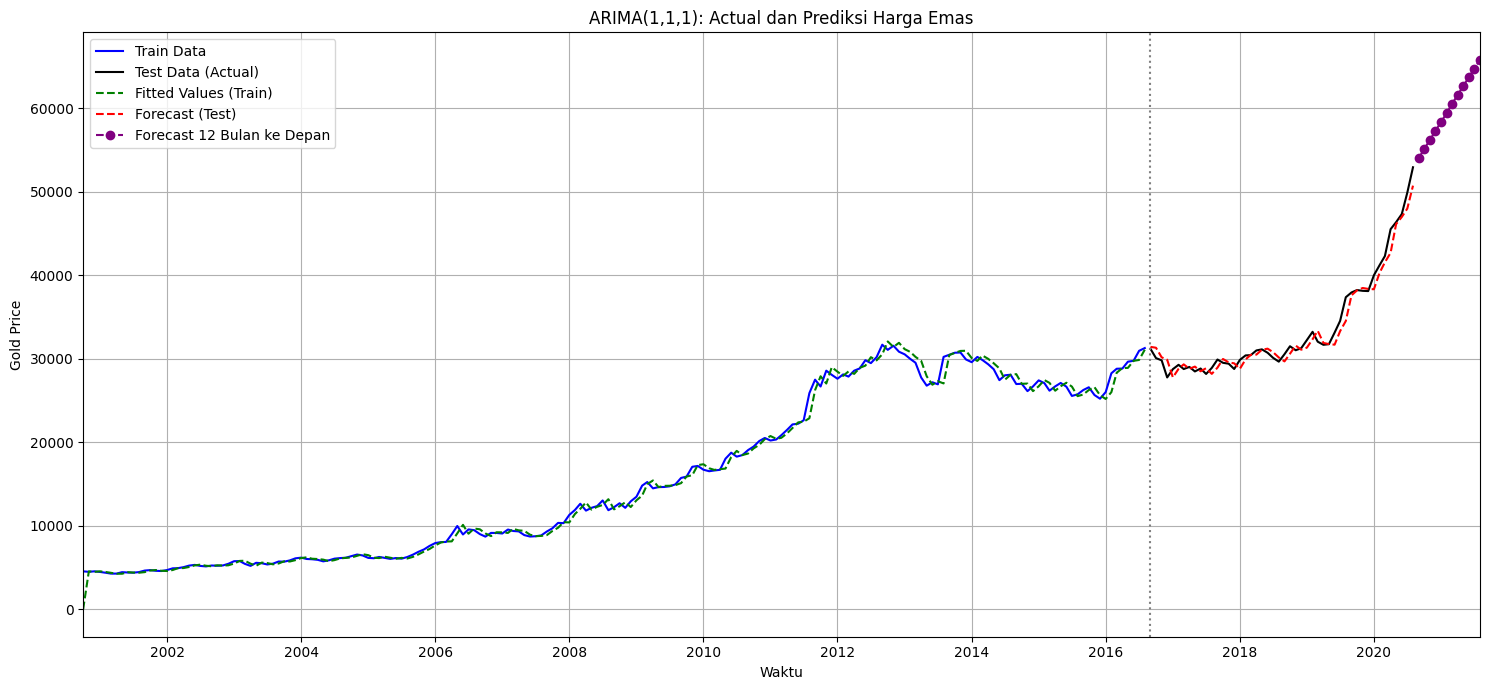

In [ ]:
# ===========================
# CEK MODEL ARIMA(1,1,1)
# ===========================

order_111 = (1, 1, 1)

model_111 = ARIMA(train, order=order_111).fit()
# ===========================
# FITTED VALUES (TRAIN)
# ===========================
fitted_train = model_111.fittedvalues

# Samakan index dengan data train
fitted_train = fitted_train.reindex(train.index)

print("\n=== SUMMARY ARIMA(1,1,1) ===")
print(model_111.summary())

# ===========================
# UJI SIGNIFIKANSI PARAMETER
# ===========================
print("\n=== Uji Signifikansi Parameter ARIMA(1,1,1) ===")
print(model_111.pvalues)

from statsmodels.stats.stattools import jarque_bera

# ===========================
# UJI LJUNG–BOX
# ===========================
print("\n=== Uji Ljung–Box ARIMA(1,1,1) ===")
lb_111 = acorr_ljungbox(model_111.resid, lags=[10], return_df=True)
print(lb_111)

if lb_111['lb_pvalue'].values[0] > 0.05:
    print("Kesimpulan Ljung–Box: Residual bersifat white noise")
else:
    print("Kesimpulan Ljung–Box: Residual masih mengandung autokorelasi")

# ===========================
# UJI JARQUE–BERA
# ===========================
print("\n=== Uji Jarque–Bera ARIMA(1,1,1) ===")
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model_111.resid)

print(f"JB Statistic : {jb_stat:.4f}")
print(f"JB P-value   : {jb_pvalue:.4f}")
print(f"Skewness     : {skew:.4f}")
print(f"Kurtosis     : {kurtosis:.4f}")

if jb_pvalue > 0.05:
    print("Kesimpulan Jarque–Bera: Residual berdistribusi normal")
else:
    print("Kesimpulan Jarque–Bera: Residual tidak berdistribusi normal")


# ===========================
# UJI ARCH
# ===========================
print("\n=== Uji ARCH ARIMA(1,1,1) ===")
arch_111 = het_arch(model_111.resid)

print(f"LM Stat    : {arch_111[0]:.4f}")
print(f"LM P-value : {arch_111[1]:.4f}")

if arch_111[1] > 0.05:
    print("Kesimpulan: Tidak ada heteroskedastisitas")
else:
    print("Kesimpulan: Ada heteroskedastisitas")

# ===========================
# FORECAST TEST (STATIC)
# ===========================
pred_111 = model_111.forecast(steps=len(test))

mse_111 = mean_squared_error(test, pred_111)
mae_111 = mean_absolute_error(test, pred_111)

print("\n=== Akurasi Forecast (Static) ===")
print("MSE:", mse_111)
print("MAE:", mae_111)

# ===========================
# ROLLING FORECAST ARIMA(1,1,1)
# ===========================
history = list(train)
rolling_111 = []

for t in range(len(test)):
    model = ARIMA(history, order=order_111)
    fit = model.fit()
    yhat = fit.forecast()[0]
    rolling_111.append(yhat)
    history.append(test.iloc[t])

mse_roll_111 = mean_squared_error(test, rolling_111)
mae_roll_111 = mean_absolute_error(test, rolling_111)

print("\n=== Akurasi Rolling Forecast (1-step) ===")
print("MSE:", mse_roll_111)
print("MAE:", mae_roll_111)

# ===========================
# INVERSE BOX–COX (NILAI ASLI)
# ===========================

train_orig = pd.Series(
    inv_boxcox(train, lambda_bc),
    index=train.index
)

test_orig = pd.Series(
    inv_boxcox(test, lambda_bc),
    index=test.index
)

fitted_orig = pd.Series(
    inv_boxcox(fitted_train.dropna(), lambda_bc),
    index=fitted_train.dropna().index
)

rolling_orig = pd.Series(
    inv_boxcox(rolling_111, lambda_bc),
    index=test.index
)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Train aktual
plt.plot(train_orig.index, train_orig,
         label="Train Data", color="blue")

# Prediksi train (fitted values)
plt.plot(fitted_orig.index, fitted_orig,
         label="Fitted Values (Train)",
         linestyle="--", color="green")

# Test aktual
plt.plot(test_orig.index, test_orig,
         label="Test Data (Actual)", color="black")

# Rolling forecast
plt.plot(rolling_orig.index, rolling_orig,
         label="Rolling Forecast ARIMA(1,1,1)",
         linestyle="--", color="red")

# Batas train-test
plt.axvline(x=test_orig.index[0],
            color="gray", linestyle=":")

plt.title("Train Prediction dan Rolling Forecast ARIMA(1,1,1)")
plt.xlabel("Waktu")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ===========================
# FORECAST 12 BULAN KE DEPAN
# ===========================

# 1. Fit model final (pakai seluruh data)
final_model = ARIMA(y_bc, order=(1,1,1)).fit()

# 2. Forecast 12 bulan (Box–Cox scale)
n_forecast = 12

forecast_res = final_model.get_forecast(steps=n_forecast)

future_forecast_bc = forecast_res.predicted_mean


# 3. Index waktu masa depan (bulanan)
freq = pd.infer_freq(y.index)

future_index = pd.date_range(
    start=y.index[-1] + pd.tseries.frequencies.to_offset(freq),
    periods=n_forecast,
    freq=freq
)


# 4. Inverse Box–Cox (nilai asli) + Series
future_forecast = pd.Series(
    inv_boxcox(future_forecast_bc, lambda_bc),
    index=future_index
)

print("\n=== Forecast 12 Bulan ke Depan ===")
print(future_forecast.round(2))

plt.figure(figsize=(15,7))

plt.plot(train_orig.index, train_orig, label="Train Data", color="blue")
plt.plot(test_orig.index, test_orig, label="Test Data (Actual)", color="black")

plt.plot(fitted_orig.index, fitted_orig,
         label="Fitted Values (Train)",
         linestyle="--", color="green")

plt.plot(rolling_orig.index, rolling_orig,
         label="Forecast (Test)",
         linestyle="--", color="red")

plt.plot(future_forecast.index, future_forecast,
         label="Forecast 12 Bulan ke Depan",
         linestyle="--", color="purple",
         marker="o")

plt.axvline(x=test_orig.index[0], color="gray", linestyle=":")

plt.xlim(train_orig.index[0], future_forecast.index[-1])

plt.title("ARIMA(1,1,1): Actual dan Prediksi Harga Emas")
plt.xlabel("Waktu")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





In [ ]:
# ========================================
# 11. ROLLING FORECAST + SIMPAN KOEFISIEN
# ========================================

history = train.copy()
test_len = len(test)

rolling_pred_bc = []
coeff_table = []   # <-- menyimpan koefisien per iterasi

for t in range(test_len):
    model = ARIMA(history, order=best_order)
    model_fit = model.fit()

    # Forecast 1 langkah ke depan
    yhat = model_fit.forecast()[0]
    rolling_pred_bc.append(yhat)

    # Simpan koefisien ke tabel
    coef = model_fit.params.to_dict()
    coef['iteration'] = t + 1
    coeff_table.append(coef)

    # Tambahkan nilai aktual ke history (fix append)
    new_val = pd.Series([test.iloc[t]], index=[test.index[t]])
    history = pd.concat([history, new_val])

# Ubah ke DataFrame
coef_df = pd.DataFrame(coeff_table)
print("\n=== Tabel Koefisien ARIMA per Iterasi ===")
print(coef_df)




=== Tabel Koefisien ARIMA per Iterasi ===
       ar.L1     ma.L1     ma.L2    sigma2  iteration
0   0.991908 -0.892878 -0.073191  2.504521          1
1   0.991695 -0.892653 -0.073078  2.492614          2
2   0.990557 -0.888807 -0.075220  2.507554          3
3   0.990306 -0.885717 -0.077873  2.496089          4
4   0.987840 -0.879823 -0.079366  2.570655          5
5   0.989150 -0.901345 -0.060760  2.582346          6
6   0.989816 -0.897943 -0.065613  2.572038          7
7   0.989060 -0.898662 -0.063358  2.565945          8
8   0.989365 -0.900249 -0.062391  2.554058          9
9   0.988621 -0.900909 -0.060182  2.548380         10
10  0.989040 -0.903200 -0.058781  2.537968         11
11  0.988188 -0.904668 -0.055504  2.535314         12
12  0.989017 -0.910058 -0.051954  2.533071         13
13  0.990223 -0.905426 -0.059213  2.535835         14
14  0.989659 -0.908428 -0.055104  2.528363         15
15  0.989554 -0.907713 -0.055604  2.516392         16
16  0.988903 -0.906498 -0.055555  2.512

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  191
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -357.043
Date:                Fri, 12 Dec 2025   AIC                            722.085
Time:                        09:12:24   BIC                            735.073
Sample:                    10-01-2000   HQIC                           727.346
                         - 08-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9919      0.015     64.641      0.000       0.962       1.022
ma.L1         -0.8929      0.070    -12.801      0.000      -1.030      -0.756
ma.L2         -0.0732      0.071     -1.028      0.3

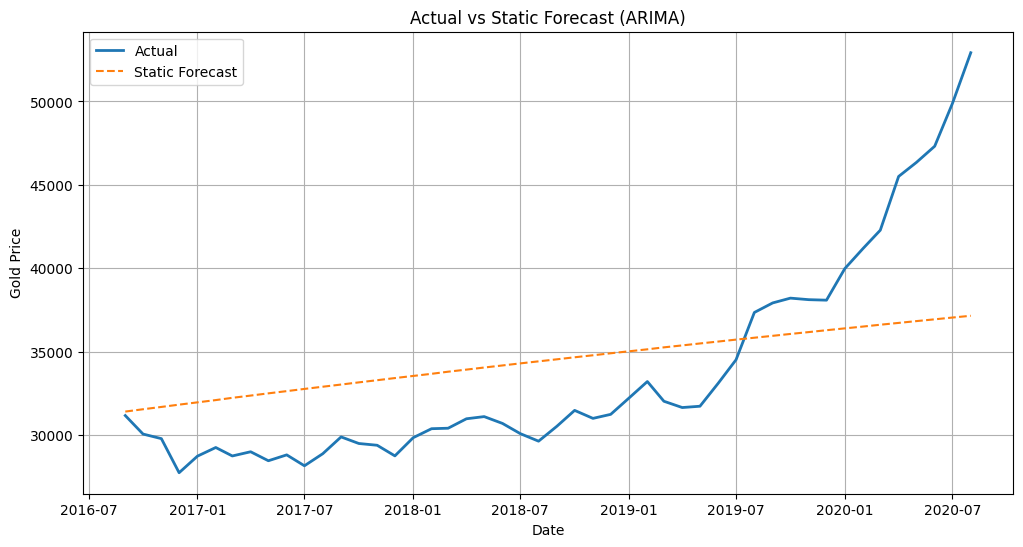

In [ ]:
# ===========================
# 1. FIT MODEL SEKALI (STATIC)
# ===========================
static_model = ARIMA(train, order=best_order).fit()

print(static_model.summary())

# ===========================
# 2. FORECAST SEKALIGUS
# ===========================
static_pred_bc = static_model.forecast(steps=len(test))

# ===========================
# 3. INVERSE BOX-COX
# ===========================
from scipy.special import inv_boxcox

test_original = inv_boxcox(test, lambda_bc)
static_pred_original = inv_boxcox(static_pred_bc, lambda_bc)

# ===========================
# 4. HITUNG METRIK
# ===========================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_static = mean_squared_error(test_original, static_pred_original)
mae_static = mean_absolute_error(test_original, static_pred_original)
r2_static = r2_score(test_original, static_pred_original)

print("\n=== STATIC FORECAST METRICS ===")
print("MSE:", mse_static)
print("MAE:", mae_static)
print("R² :", r2_static)

# ===========================
# 5. PLOT ACTUAL VS STATIC FORECAST
# ===========================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test_original.index, test_original.values, label='Actual', linewidth=2)
plt.plot(test_original.index, static_pred_original, '--', label='Static Forecast')

plt.title("Actual vs Static Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True)
plt.show()



=== PERBANDINGAN STATIC VS ROLLING FORECAST ===

                           MSE          MAE        R²
Static Forecast   2.464050e+07  4072.671613  0.359683
Rolling Forecast  1.047938e+06   776.715555  0.972768


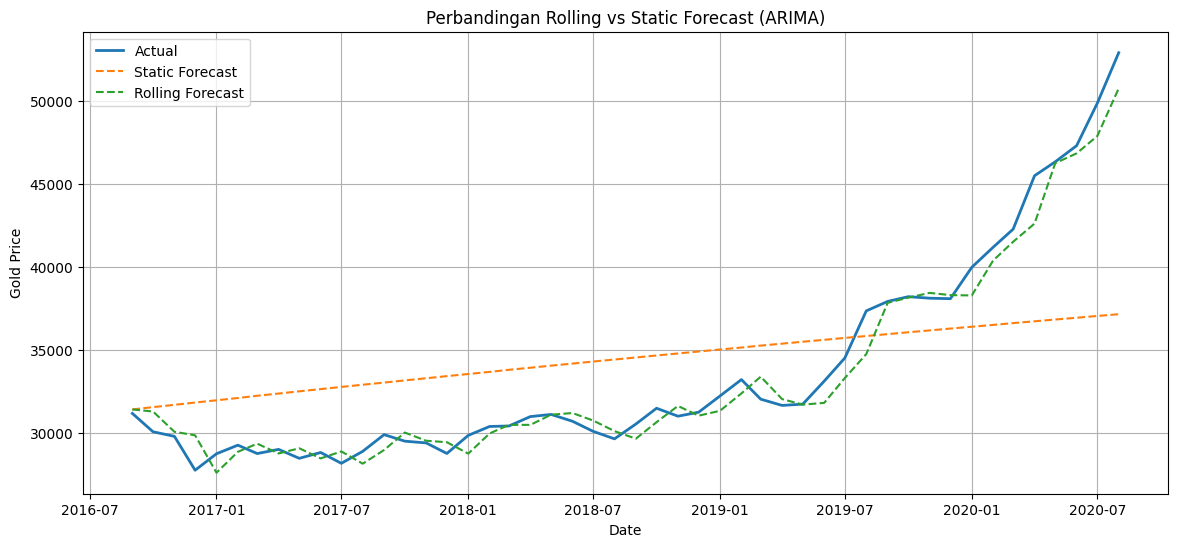

In [ ]:
# ===========================================================
# 1. STATIC FORECAST (fit model sekali)
# ===========================================================
static_model = ARIMA(train, order=best_order).fit()
static_pred_bc = static_model.forecast(steps=len(test))

# Inverse Box-Cox
from scipy.special import inv_boxcox
test_original = inv_boxcox(test, lambda_bc)
static_pred_original = inv_boxcox(static_pred_bc, lambda_bc)


# ===========================================================
# 2. HITUNG METRIK STATIC
# ===========================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_static = mean_squared_error(test_original, static_pred_original)
mae_static = mean_absolute_error(test_original, static_pred_original)
r2_static  = r2_score(test_original, static_pred_original)


# ===========================================================
# 3. HITUNG METRIK ROLLING (rolling_original sudah dibuat sebelumnya)
# ===========================================================
mse_rolling = mean_squared_error(test_original, rolling_original)
mae_rolling = mean_absolute_error(test_original, rolling_original)
r2_rolling  = r2_score(test_original, rolling_original)


# ===========================================================
# 4. CETAK TABEL PERBANDINGAN
# ===========================================================
import pandas as pd

comparison_df = pd.DataFrame({
    "MSE":  [mse_static, mse_rolling],
    "MAE":  [mae_static, mae_rolling],
    "R²":   [r2_static,  r2_rolling]
}, index=["Static Forecast", "Rolling Forecast"])

print("\n=== PERBANDINGAN STATIC VS ROLLING FORECAST ===\n")
print(comparison_df)


# ===========================================================
# 5. PLOT GABUNGAN ACTUAL VS STATIC VS ROLLING
# ===========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(test_original.index, test_original.values,
         label='Actual', linewidth=2)
plt.plot(test_original.index, static_pred_original,
         label='Static Forecast', linestyle='--')
plt.plot(test_original.index, rolling_original,
         label='Rolling Forecast', linestyle='--')

plt.title("Perbandingan Rolling vs Static Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True)
plt.show()


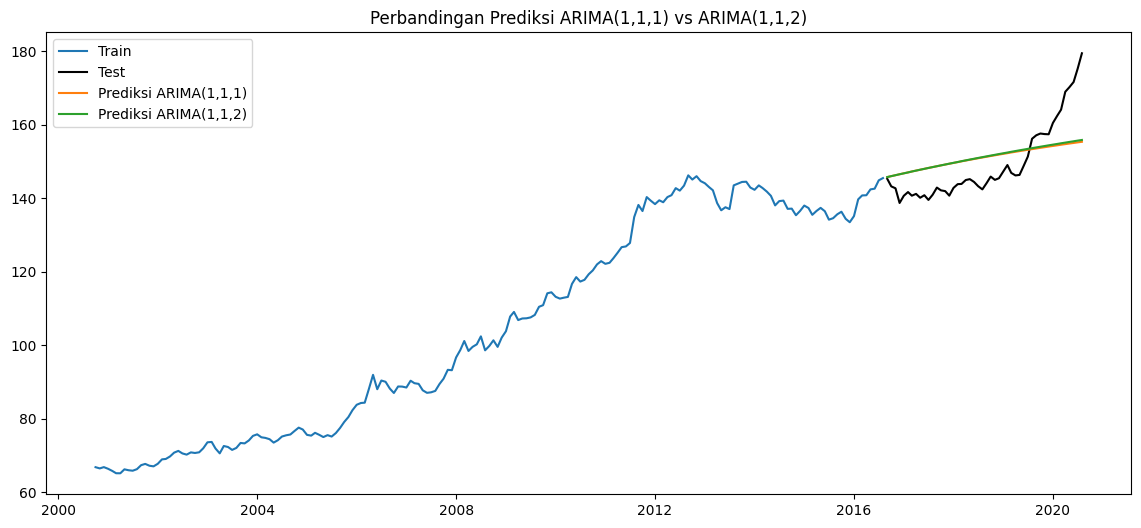

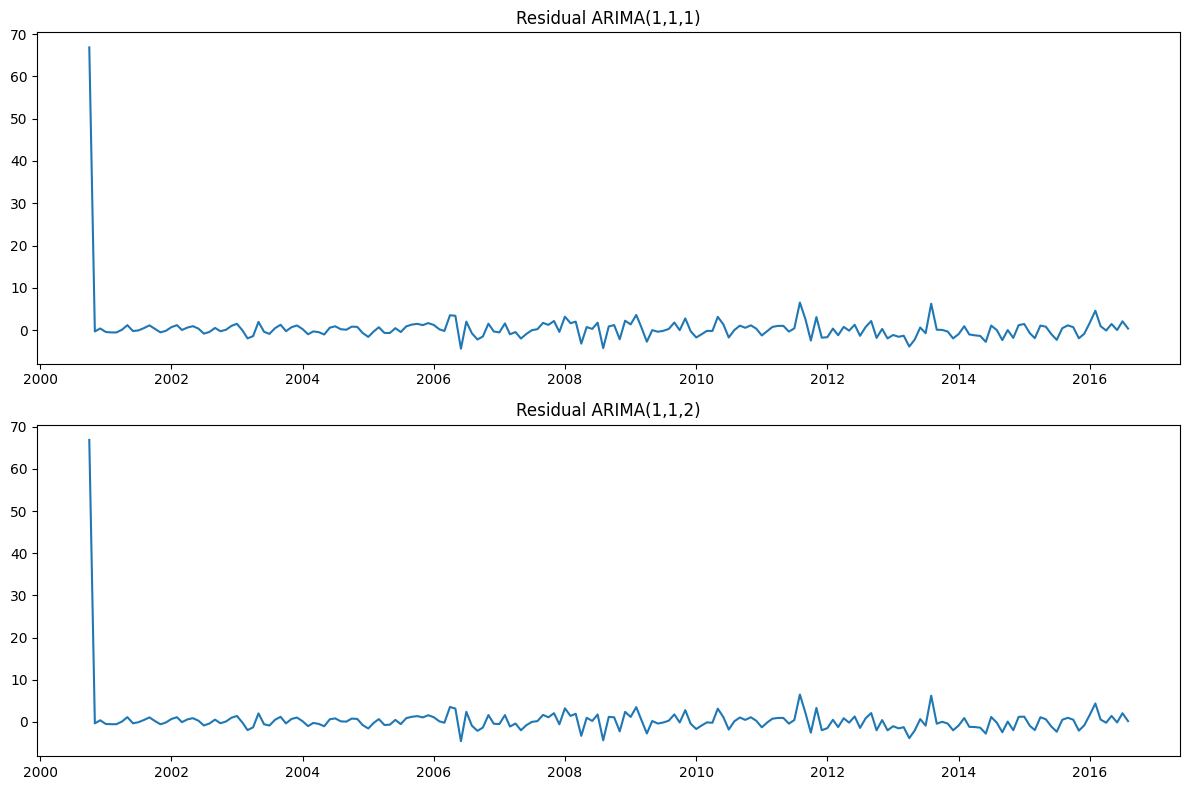

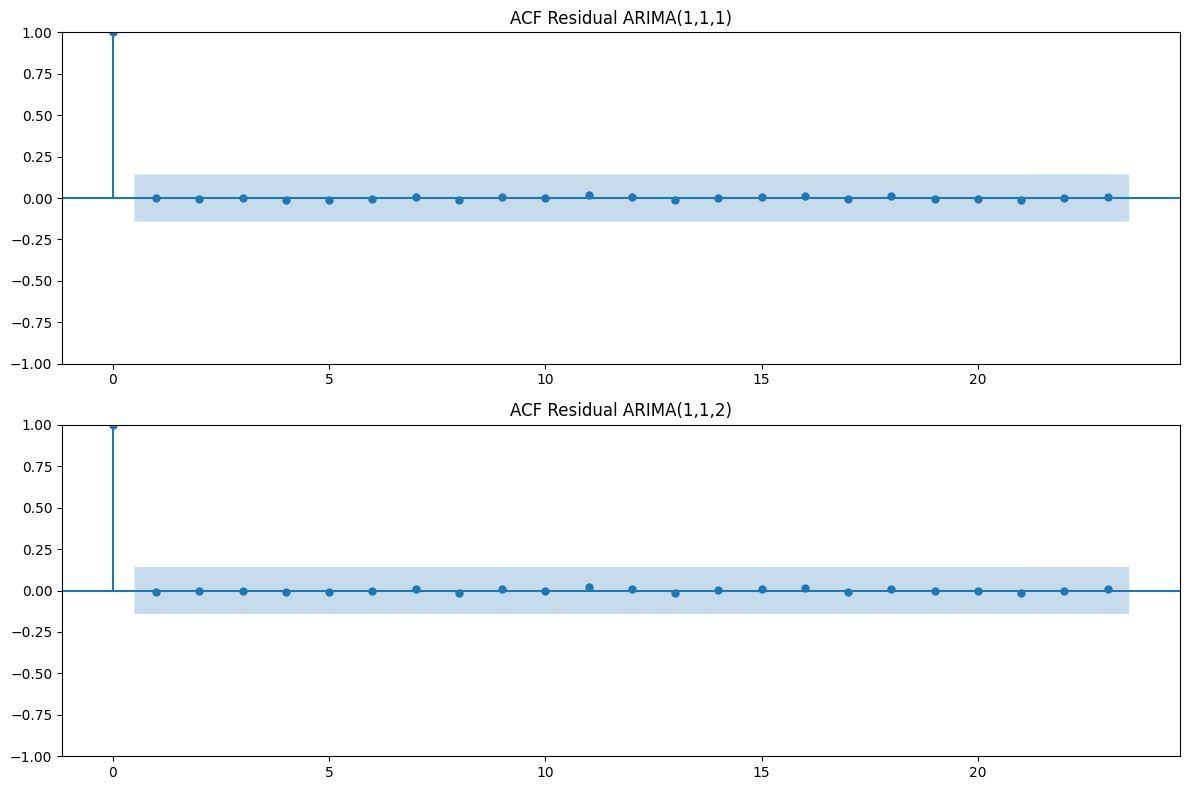

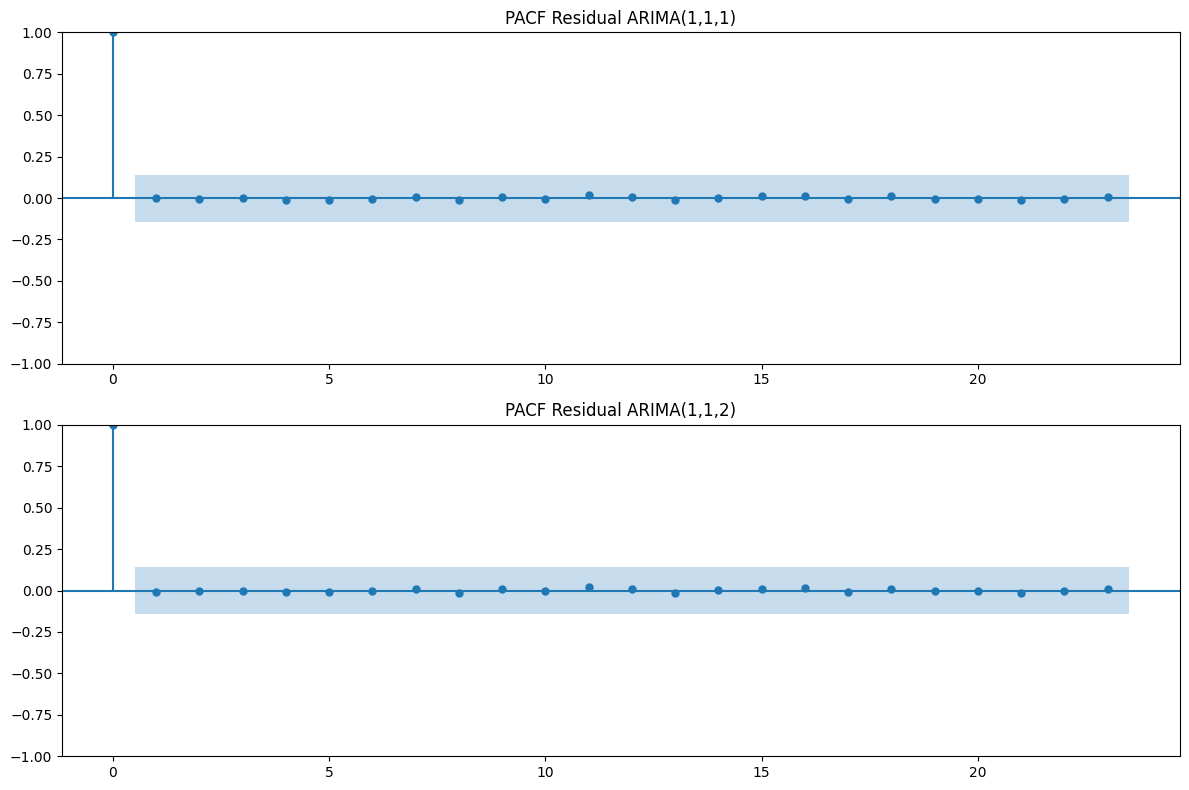

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ===========================
# FIT MODEL 1: ARIMA(1,1,1)
# ===========================
model_111 = ARIMA(train, order=(1,1,1)).fit()
pred_111 = model_111.forecast(steps=len(test))
resid_111 = model_111.resid

# ===========================
# FIT MODEL 2: ARIMA(1,1,2)
# ===========================
model_112 = ARIMA(train, order=(1,1,2)).fit()
pred_112 = model_112.forecast(steps=len(test))
resid_112 = model_112.resid

# ===========================
# 1. PLOT DATA + PREDIKSI
# ===========================
plt.figure(figsize=(14,6))
plt.plot(train, label="Train")
plt.plot(test, label="Test", color="black")

plt.plot(pred_111, label="Prediksi ARIMA(1,1,1)")
plt.plot(pred_112, label="Prediksi ARIMA(1,1,2)")

plt.title("Perbandingan Prediksi ARIMA(1,1,1) vs ARIMA(1,1,2)")
plt.legend()
plt.show()

# ===========================
# 2. PLOT RESIDUAL
# ===========================
fig, ax = plt.subplots(2, 1, figsize=(12,8))

ax[0].plot(resid_111)
ax[0].set_title("Residual ARIMA(1,1,1)")

ax[1].plot(resid_112)
ax[1].set_title("Residual ARIMA(1,1,2)")

plt.tight_layout()
plt.show()

# ===========================
# 3. ACF RESIDUAL
# ===========================
fig, ax = plt.subplots(2, 1, figsize=(12,8))

plot_acf(resid_111, ax=ax[0])
ax[0].set_title("ACF Residual ARIMA(1,1,1)")

plot_acf(resid_112, ax=ax[1])
ax[1].set_title("ACF Residual ARIMA(1,1,2)")

plt.tight_layout()
plt.show()

# ===========================
# 4. PACF RESIDUAL
# ===========================
fig, ax = plt.subplots(2, 1, figsize=(12,8))

plot_pacf(resid_111, ax=ax[0])
ax[0].set_title("PACF Residual ARIMA(1,1,1)")

plot_pacf(resid_112, ax=ax[1])
ax[1].set_title("PACF Residual ARIMA(1,1,2)")

plt.tight_layout()
plt.show()


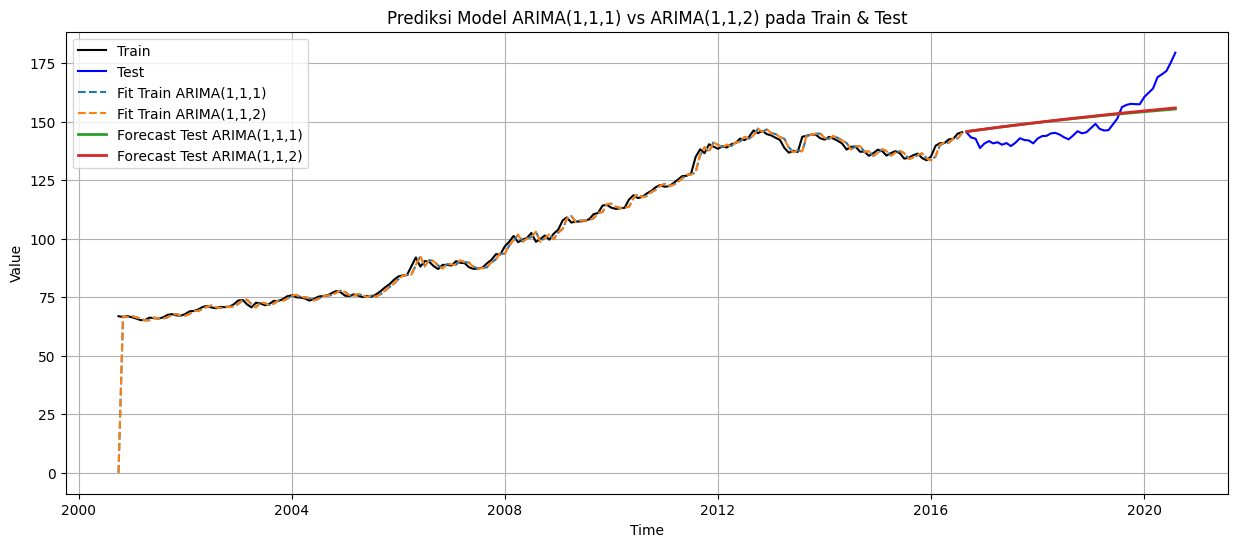

In [ ]:
# ===========================
# Prediksi IN-SAMPLE (Train)
# ===========================
fitted_111 = model_111.fittedvalues
fitted_112 = model_112.fittedvalues

# ===========================
# Prediksi OUT-SAMPLE (Test)
# ===========================
forecast_111 = model_111.forecast(steps=len(test))
forecast_112 = model_112.forecast(steps=len(test))

# ===========================
# Plot
# ===========================
plt.figure(figsize=(15,6))

plt.plot(train, label="Train", color="black")
plt.plot(test, label="Test", color="blue")

# In-sample fit
plt.plot(fitted_111, label="Fit Train ARIMA(1,1,1)", linestyle="--")
plt.plot(fitted_112, label="Fit Train ARIMA(1,1,2)", linestyle="--")

# Out-sample forecast
plt.plot(test.index, forecast_111, label="Forecast Test ARIMA(1,1,1)", linewidth=2)
plt.plot(test.index, forecast_112, label="Forecast Test ARIMA(1,1,2)", linewidth=2)

plt.title("Prediksi Model ARIMA(1,1,1) vs ARIMA(1,1,2) pada Train & Test")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()
